In [1]:
import numpy as np
import matplotlib.pyplot as plt
from vae_definition import VAE
import torch

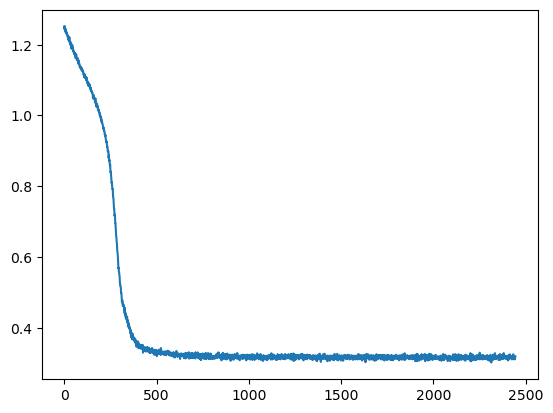

In [2]:
fig, ax = plt.subplots()
losses = np.load("vae_losses.npy")

ax.plot(losses)

torch.Size([1000, 32])
tensor([[ 5.3467e-01,  1.1033e-08,  1.5670e-07,  ..., -1.3324e-03,
          2.1015e-03,  6.0400e+03],
        [ 5.3431e-01,  1.1028e-08,  1.3469e-07,  ..., -1.3299e-03,
          2.0754e-03,  6.0400e+03],
        [ 5.3458e-01,  1.1032e-08,  1.5157e-07,  ..., -1.3318e-03,
          2.0952e-03,  6.0400e+03],
        ...,
        [ 5.3457e-01,  1.1032e-08,  1.5076e-07,  ..., -1.3317e-03,
          2.0941e-03,  6.0400e+03],
        [ 5.3420e-01,  1.1026e-08,  1.2806e-07,  ..., -1.3291e-03,
          2.0677e-03,  6.0400e+03],
        [ 5.3414e-01,  1.1025e-08,  1.2445e-07,  ..., -1.3287e-03,
          2.0638e-03,  6.0400e+03]])


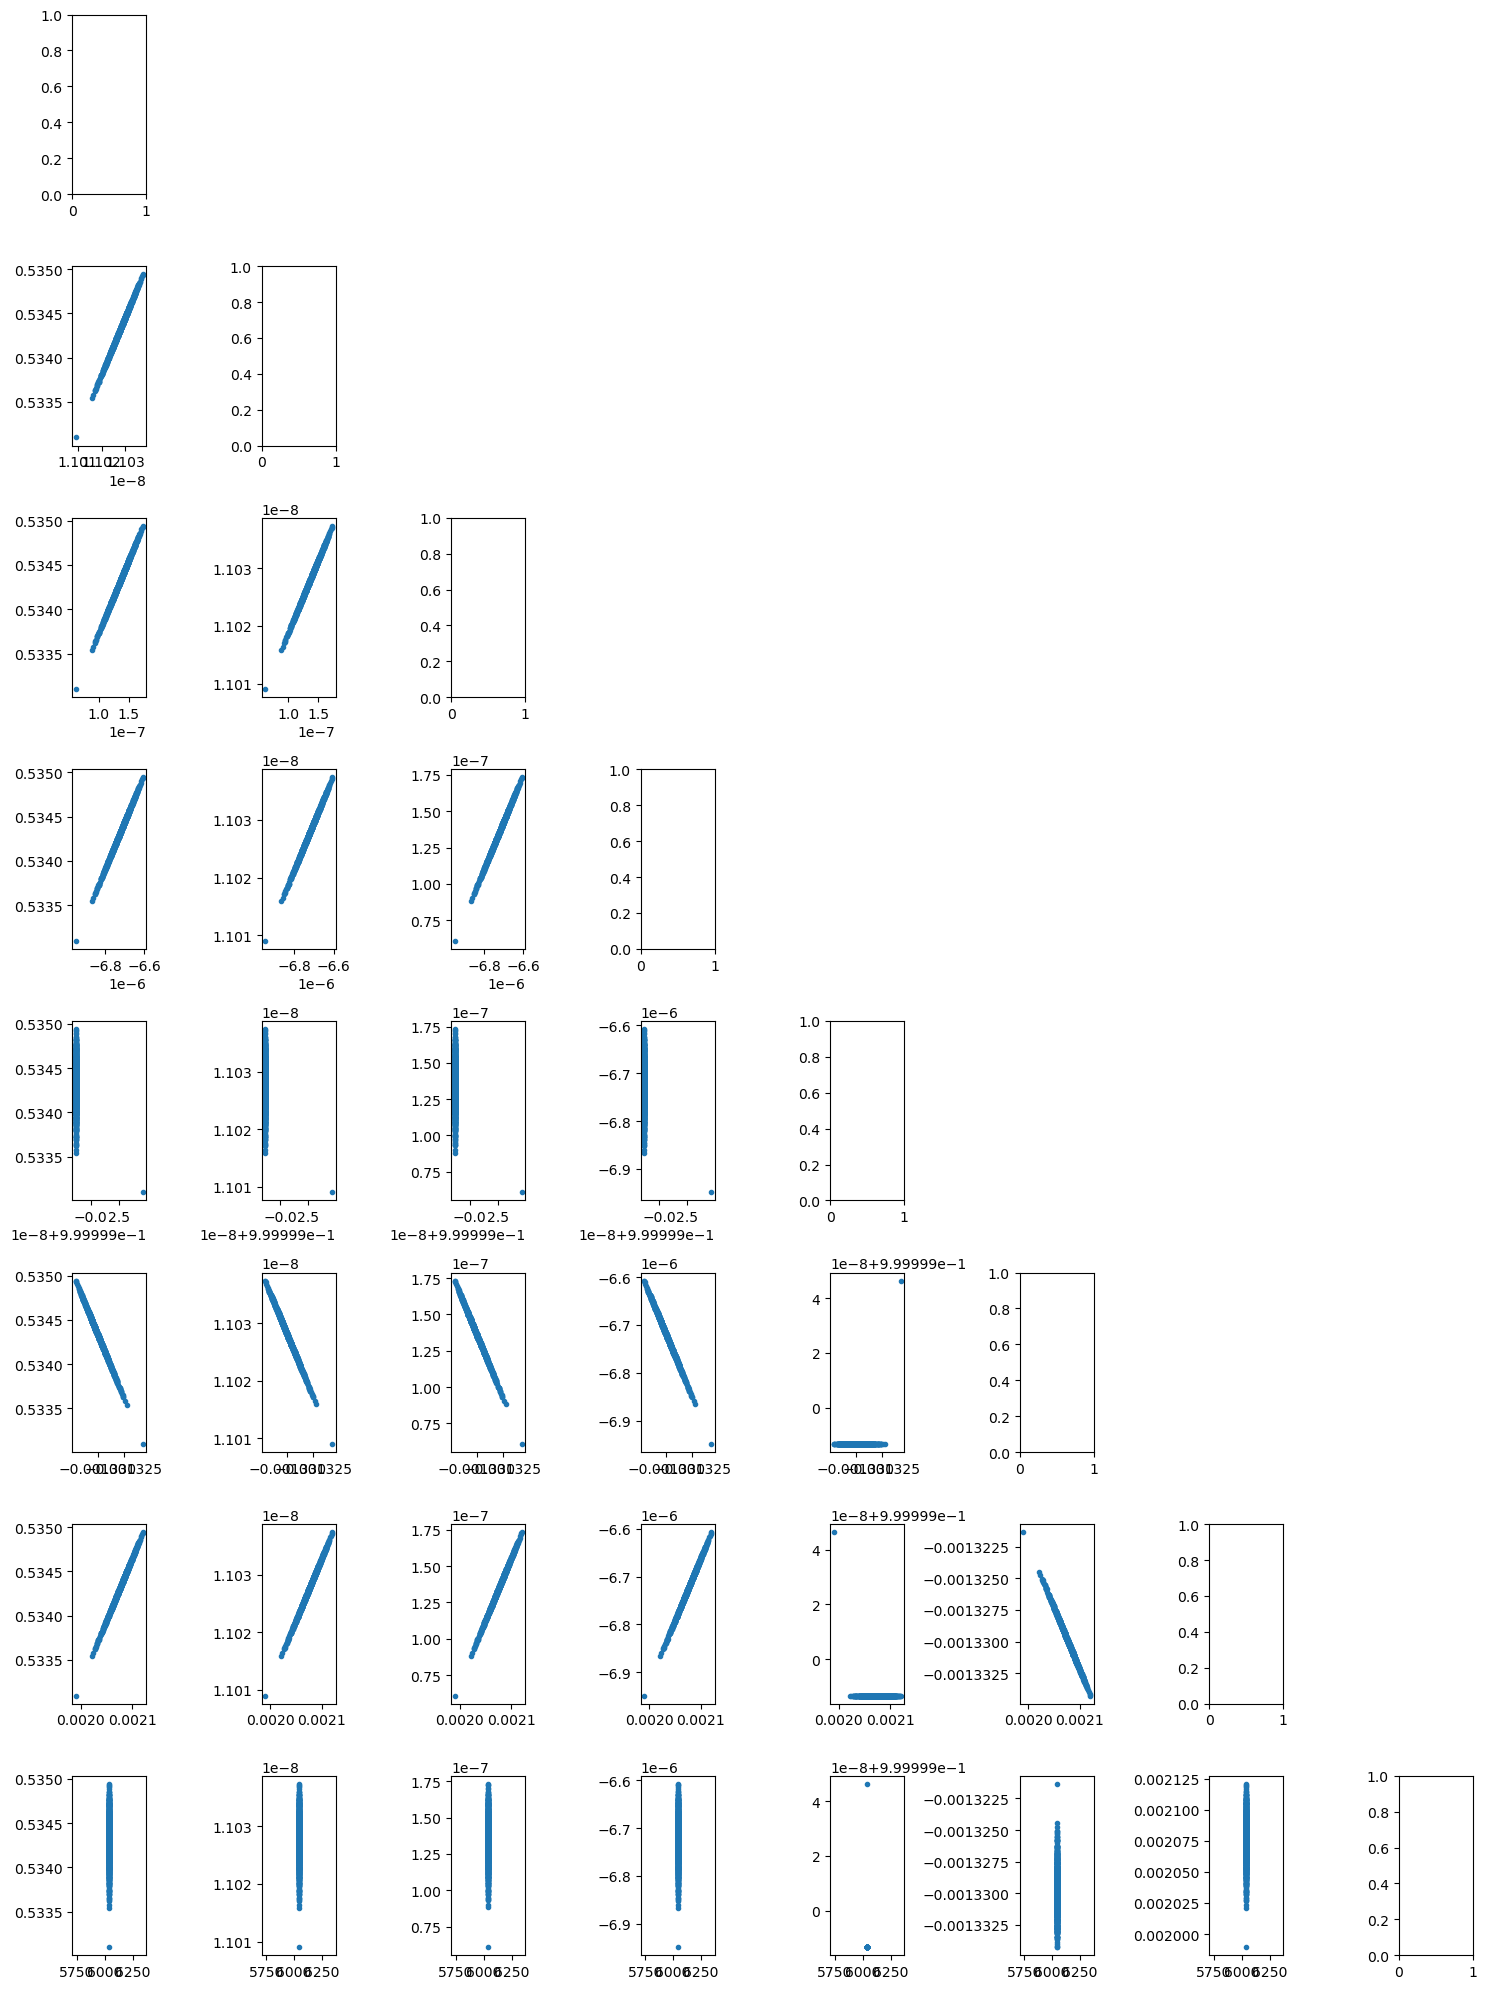

In [3]:
# sample_from_vae.py
device = "mps"

ckpt = torch.load("vae.pth", map_location=device)

vae = VAE().to(device)
vae.load_state_dict(ckpt["state_dict"])
vae.eval()

mins = ckpt["mins"].to(device)       
scales = ckpt["scales"].to(device)  


with torch.no_grad():
    z = torch.randn(1000,32).to(device)  # sample 1000 latent vectors
    print(z.shape)
    samples = vae.decode(z)              # synthetic data in [0,1]
    samples = samples.clamp(0,1)
    samples = samples * scales + mins
samples = samples.cpu()
print(samples.cpu())
fig, ax = plt.subplots(ncols=8, nrows=8, figsize=(15,20))
for i in range(8):
    for j in range(8):
        if j>i:
            ax[i,j].set_axis_off()
            continue
        if j==i:
            # ax[i,j].hist(samples[:,i], bins=10)
            continue
        ax[i,j].plot(samples[:,i],samples[:,j], '.')
plt.tight_layout()
